In [171]:
import pandas as pd
import numpy as np
import os
import time
from catboost import CatBoostRegressor
from xgboost import XGBRegressor 
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from lightgbm import LGBMRegressor
import optuna

In [172]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [173]:
def add_feature_cross_terms(df, features):
    df_new = df.copy()
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            f1 = features[i]
            f2 = features[j]
            df_new[f"{f1}_x_{f2}"] = df_new[f1] * df_new[f2]
    return df_new

num_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
train = add_feature_cross_terms(train, num_features)
test = add_feature_cross_terms(test, num_features)

In [174]:
train['Sex'] = train['Sex'].map({'male' : 0, 'female' : 1}).astype('category')
test['Sex'] = test['Sex'].map({'male' : 0, 'female' : 1}).astype('category')

In [175]:
X = train.drop(columns=['id', 'Calories'])
y = np.log1p(train['Calories'])
X_test = test.drop(columns=['id'])

In [176]:
folds = 50
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

In [177]:
oof_cb = np.zeros(len(train))
oof_xgb = np.zeros(len(train))
oof_lgbm = np.zeros(len(train))
pred_cb = np.zeros(len(test))
pred_xgb = np.zeros(len(test))
pred_lgbm = np.zeros(len(test))

In [178]:
'''
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 1000, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42
    }
    
    oof = np.zeros(len(train))
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = CatBoostRegressor(
            **params,
            cat_features=[X.columns.get_loc('Sex')],
            verbose=0
        )
        

        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)
        

        oof[val_idx] = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y, oof))

    trial.set_user_attr("rmse", rmse)
    
    return rmse
'''

'\ndef objective(trial):\n\n    params = {\n        "iterations": trial.suggest_int("iterations", 1000, 3000),\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),\n        "depth": trial.suggest_int("depth", 4, 10),\n        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),\n        "loss_function": "RMSE",\n        "eval_metric": "RMSE",\n        "random_seed": 42\n    }\n    \n    oof = np.zeros(len(train))\n    \n    for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):\n        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]\n        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]\n        \n        model = CatBoostRegressor(\n            **params,\n            cat_features=[X.columns.get_loc(\'Sex\')],\n            verbose=0\n        )\n        \n\n        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)\n        \n\n        oof[val_idx] = model.predict(X_val)\n    \n    rmse = np.sqrt(mean_squared_er

In [179]:
'''
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50)

print("Best trial:")
trial = study.best_trial
print("  RMSE: {}".format(trial.value))
print("  Best hyperparameters: {}".format(trial.params))
'''

'\nstudy = optuna.create_study(direction="minimize")\n\nstudy.optimize(objective, n_trials=50)\n\nprint("Best trial:")\ntrial = study.best_trial\nprint("  RMSE: {}".format(trial.value))\nprint("  Best hyperparameters: {}".format(trial.params))\n'

In [180]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"CatBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model_cb = CatBoostRegressor(
        iterations=2000
        , learning_rate=0.2
        , depth=10
        , l2_leaf_reg=3
        , cat_features=[X.columns.get_loc('Sex')]
        , loss_function='RMSE'
        , eval_metric='RMSE'
        , early_stopping_rounds=100
    )
    
    model_cb.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    oof_cb[val_idx] = model_cb.predict(X_val)
    pred_cb += model_cb.predict(X_test)

CatBoost Fold 1
CatBoost Fold 2
CatBoost Fold 3
CatBoost Fold 4
CatBoost Fold 5
CatBoost Fold 6
CatBoost Fold 7
CatBoost Fold 8
CatBoost Fold 9
CatBoost Fold 10
CatBoost Fold 11
CatBoost Fold 12
CatBoost Fold 13
CatBoost Fold 14
CatBoost Fold 15
CatBoost Fold 16
CatBoost Fold 17
CatBoost Fold 18
CatBoost Fold 19
CatBoost Fold 20
CatBoost Fold 21
CatBoost Fold 22
CatBoost Fold 23
CatBoost Fold 24
CatBoost Fold 25
CatBoost Fold 26
CatBoost Fold 27
CatBoost Fold 28
CatBoost Fold 29
CatBoost Fold 30
CatBoost Fold 31
CatBoost Fold 32
CatBoost Fold 33
CatBoost Fold 34
CatBoost Fold 35
CatBoost Fold 36
CatBoost Fold 37
CatBoost Fold 38
CatBoost Fold 39
CatBoost Fold 40
CatBoost Fold 41
CatBoost Fold 42
CatBoost Fold 43
CatBoost Fold 44
CatBoost Fold 45
CatBoost Fold 46
CatBoost Fold 47
CatBoost Fold 48
CatBoost Fold 49
CatBoost Fold 50


In [181]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"XGBoost Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_xgb = XGBRegressor(
        max_depth=10
        , colsample_bytree=0.75
        , subsample=0.9
        , n_estimators=2000
        , learning_rate=0.02
        , gamma=0.01
        , max_delta_step=2
        , enable_categorical=True
        , eval_metric="rmse"
        , early_stopping_rounds=100
        )
    
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val_idx] = model_xgb.predict(X_val)
    pred_xgb += model_xgb.predict(X_test)

XGBoost Fold 1
XGBoost Fold 2
XGBoost Fold 3
XGBoost Fold 4
XGBoost Fold 5
XGBoost Fold 6
XGBoost Fold 7
XGBoost Fold 8
XGBoost Fold 9
XGBoost Fold 10
XGBoost Fold 11
XGBoost Fold 12
XGBoost Fold 13
XGBoost Fold 14
XGBoost Fold 15
XGBoost Fold 16
XGBoost Fold 17
XGBoost Fold 18
XGBoost Fold 19
XGBoost Fold 20
XGBoost Fold 21
XGBoost Fold 22
XGBoost Fold 23
XGBoost Fold 24
XGBoost Fold 25
XGBoost Fold 26
XGBoost Fold 27
XGBoost Fold 28
XGBoost Fold 29
XGBoost Fold 30
XGBoost Fold 31
XGBoost Fold 32
XGBoost Fold 33
XGBoost Fold 34
XGBoost Fold 35
XGBoost Fold 36
XGBoost Fold 37
XGBoost Fold 38
XGBoost Fold 39
XGBoost Fold 40
XGBoost Fold 41
XGBoost Fold 42
XGBoost Fold 43
XGBoost Fold 44
XGBoost Fold 45
XGBoost Fold 46
XGBoost Fold 47
XGBoost Fold 48
XGBoost Fold 49
XGBoost Fold 50


In [182]:
for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"LGBM Fold {fold+1}")
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model_lgbm = LGBMRegressor(
    n_estimators=2000
    , learning_rate=0.02
    , num_leaves=30
    , max_depth=10
    , min_child_samples=20
    , subsample=0.8
    , colsample_bytree=0.8
    , objective='regression'
    , metric='rmse'
    , verbose=-1
    )
    
    model_lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='rmse')
    oof_lgbm[val_idx] = model_lgbm.predict(X_val)
    pred_lgbm += model_lgbm.predict(X_test)

LGBM Fold 1
LGBM Fold 2
LGBM Fold 3
LGBM Fold 4
LGBM Fold 5
LGBM Fold 6
LGBM Fold 7
LGBM Fold 8
LGBM Fold 9
LGBM Fold 10
LGBM Fold 11
LGBM Fold 12
LGBM Fold 13
LGBM Fold 14
LGBM Fold 15
LGBM Fold 16
LGBM Fold 17
LGBM Fold 18
LGBM Fold 19
LGBM Fold 20
LGBM Fold 21
LGBM Fold 22
LGBM Fold 23
LGBM Fold 24
LGBM Fold 25
LGBM Fold 26
LGBM Fold 27
LGBM Fold 28
LGBM Fold 29
LGBM Fold 30
LGBM Fold 31
LGBM Fold 32
LGBM Fold 33
LGBM Fold 34
LGBM Fold 35
LGBM Fold 36
LGBM Fold 37
LGBM Fold 38
LGBM Fold 39
LGBM Fold 40
LGBM Fold 41
LGBM Fold 42
LGBM Fold 43
LGBM Fold 44
LGBM Fold 45
LGBM Fold 46
LGBM Fold 47
LGBM Fold 48
LGBM Fold 49
LGBM Fold 50


In [183]:
pred_cb_adj = pred_cb / folds
pred_xgb_adj = pred_xgb / folds
pred_lgbm_adj = pred_lgbm / folds

In [ ]:
def ensemble_rmse(weights, oof_cb, oof_xgb, oof_lgbm, y):
    
    ensemble_pred = weights[0] * oof_cb + weights[1] * oof_xgb + weights[2] * oof_lgbm
    
    rmse = np.sqrt(mean_squared_error(y, ensemble_pred))
    return rmse

In [ ]:
def hill_climbing_ensemble(oof_cb, oof_xgb, oof_lgbm, y, init_weights=[1/3, 1/3, 1/3], step=0.01, max_iter=1000):
    best_weights = np.array(init_weights)
    best_score = ensemble_rmse(best_weights, oof_cb, oof_xgb, oof_lgbm, y)
    improved = True
    iteration = 0
    while improved and iteration < max_iter:
        improved = False
        iteration += 1

        for i in range(len(best_weights)):
            for delta in [step, -step]:
                new_weights = best_weights.copy()
                new_weights[i] += delta

                new_weights = new_weights / new_weights.sum()
                new_score = ensemble_rmse(new_weights, oof_cb, oof_xgb, oof_lgbm, y)

                if new_score < best_score:
                    best_score = new_score
                    best_weights = new_weights
                    improved = True
                    print(f"Iteration {iteration}: Improved RMSE: {best_score:.5f} with weights {best_weights}")
                    
    return best_weights, best_score

best_weights, best_score = hill_climbing_ensemble(oof_cb, oof_xgb, oof_lgbm, y)
print("Best ensemble weights found:", best_weights)
print("Best RMSE in log space (equivalent to RMSLE):", best_score)

In [ ]:
oof_pred_log = best_weights[0] * oof_cb + best_weights[1] * oof_xgb + best_weights[2] * oof_lgbm

In [206]:
oof_preds = np.expm1(oof_pred_log)

In [207]:
rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_preds))
print("Train RMSLE Score:", rmsle_score)

Train RMSLE Score: 0.05927761808300397


In [208]:
oof_preds_clipped = np.clip(oof_preds, 1, 314)
rmsle_score = np.sqrt(mean_squared_log_error(train['Calories'], oof_preds))
print("Train Clipped RMSLE Score:", rmsle_score)

Train Clipped RMSLE Score: 0.05927761808300397


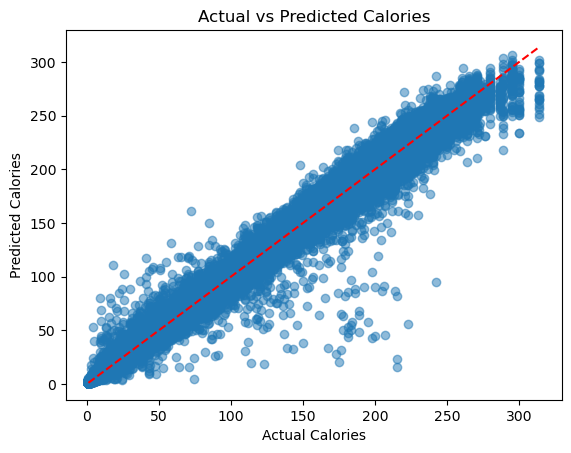

In [209]:
plt.scatter(train['Calories'], oof_preds, alpha=0.5)
plt.plot([train['Calories'].min(), train['Calories'].max()], [train['Calories'].min(), train['Calories'].max()], color='red', linestyle='--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories')
plt.show()

In [ ]:
final_pred_log = 0.51251431 * pred_cb_adj + 0.48748569 * pred_xgb_adj + 0.23768477 * pred_lgbm_adj

'+ 0.23768477 * pred_lgbm_adj'

In [211]:
final_preds = np.expm1(final_pred_log)

In [212]:
final_preds_clipped = np.clip(final_preds, 1, 314)

In [213]:
submission['Calories'] = final_preds_clipped
submission.to_csv('submission.csv', index=False)